In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ( Conv2D, MaxPooling2D, Flatten, Dense
)

from sklearn.metrics import ( classification_report, confusion_matrix)

print("TensorFlow Version:", tf.__version__)


from tensorflow.keras.layers import Dropout, BatchNormalization


TensorFlow Version: 2.20.0


####Conv2D := Creates convolution layers.
####Pooling := Reduces image dimensions.
####Dense := Regular neural network layers.
####Flatten := Converts image features into a single vector.


  

we know
50,000 training images
10,000 testing images
32×32 pixels
RGB images

for training
(50000,32,32,3)
for validation
(10000,32,32,3)

In [25]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

print("Training Images Shape :", train_images.shape)
print("Training Labels Shape :", train_labels.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)


In [26]:
print("Testing Images Shape  :", test_images.shape)
print("Testing Labels Shape  :", test_labels.shape)

Testing Images Shape  : (10000, 32, 32, 3)
Testing Labels Shape  : (10000, 1)


In [ ]:
train_images.shape

(50000, 32, 32, 3)

50000 = Number of images

32 = Height

32 = Width

3 = RGB channels.       [255,0,0] means pure red
                        [0,255,0] means pure green

In [27]:
print(train_images[0].shape)

(32, 32, 3)


In [ ]:
print(train_images.dtype)

print(train_images.min())  #0=dark, 255=bright
print(train_images.max())  #for cnn we'll later convert 0-255 to 0-1 learns better

uint8
0
255


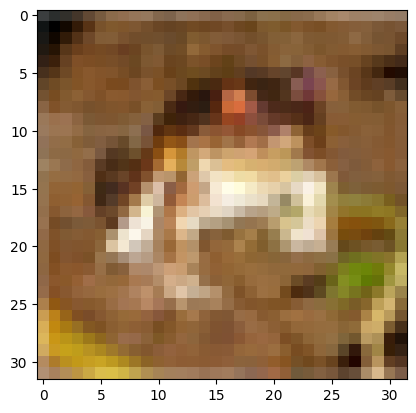

In [ ]:
plt.imshow(train_images[0])
plt.show()

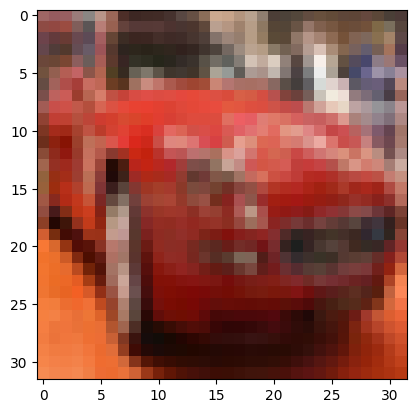

In [ ]:
plt.imshow(train_images[5])
plt.show()

In [28]:
print(train_labels[0]) #labels

[6]


In [30]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [31]:
print(class_names[train_labels[0][0]])

frog


In [32]:
print(class_names[train_labels[5][0]])

automobile


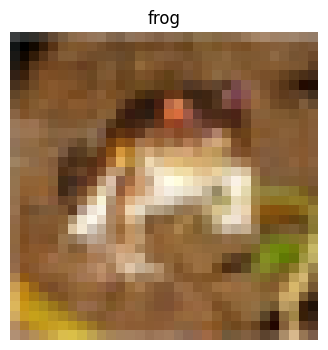

In [33]:
#displaying image with label

plt.figure(figsize=(4,4))

plt.imshow(train_images[0])

plt.title(class_names[train_labels[0][0]])

plt.axis('off') #turned off axis numbers

plt.show()

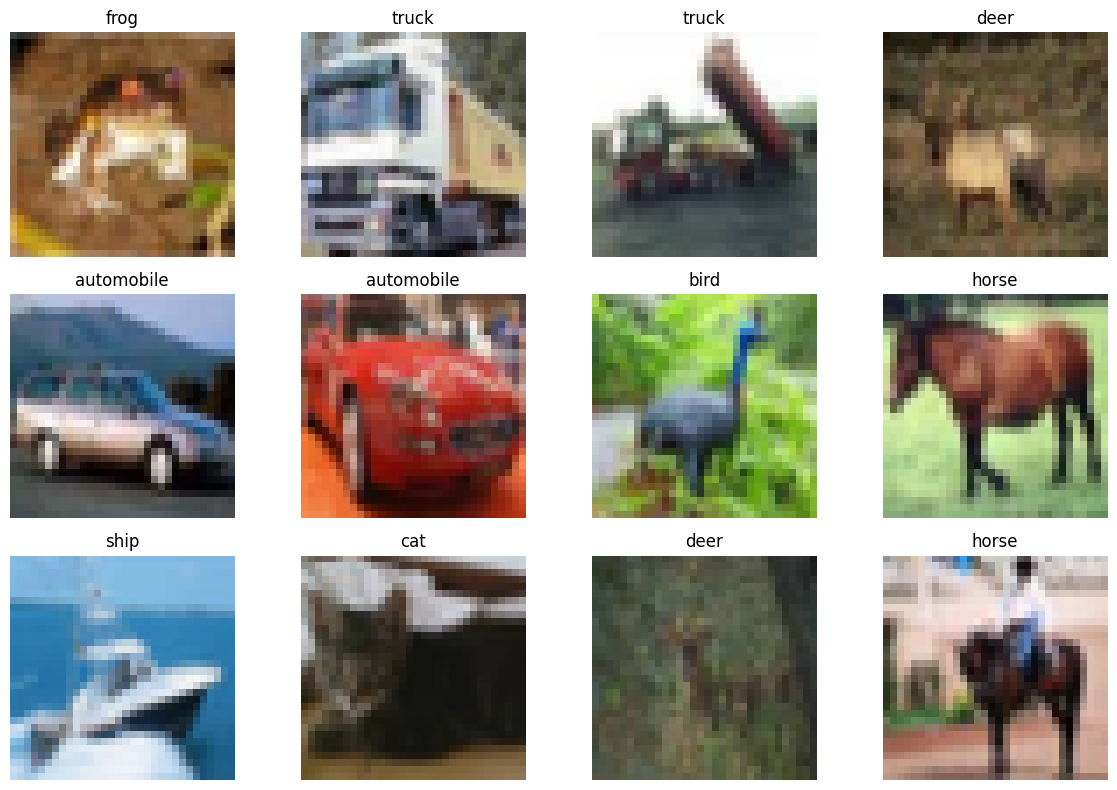

In [34]:
#showing multiple images
plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(train_images[i])

    plt.title(class_names[train_labels[i][0]])

    plt.axis('off')

plt.tight_layout()

plt.show()

In [35]:
#class distribution
unique, counts = np.unique(train_labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{class_names[label]} : {count}")

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


Every class has same number of images (balanced Dataset)

In [36]:
#normalizing for cnn
train_images= train_images/255.0
test_images = test_images/255.0


In [ ]:
print(train_images.min())
print(train_images.max())

0.0
1.0


In [14]:
model = Sequential()

# 1st Convolution Block
model.add(
     Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolution Block
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Param # = 896?
Each filter:
3 × 3 × 3
because:
3 × 3 kernel
3 RGB channels

Parameters per filter:
3 × 3 × 3 = 27
plus:
1 bias

Total:
28

For 32 filters:
28 x 32 = 896

or flatten
6 x 6 x 64
=2304

Flatten converts:

3D feature maps into: 1D vector for Dense layers.

Dense layer
(2304 x 64) +64 biases=147,520

Output Layer
(None, 10)

because:

10 classes

Softmax converts everything into probabilities.

In [15]:
#compiling model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', #because train labels are integers not one-hot encoded
    metrics=['accuracy']
)

#standard Categorical Cross-Entropy: convert your targets into a massive 2D matrix of size (64, 10000).
# RAM has to store 640,000 numbers per single step—and 99.9% of them are just useless zeros

# using Sparse Categorical Cross-Entropy: target array stays as a simple 1D list of 64 integers: [3, 402, 11, 9841, ...]

Doing Basic CNN first

In [39]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.4849 - loss: 1.4328 - val_accuracy: 0.5905 - val_loss: 1.1869
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6188 - loss: 1.0920 - val_accuracy: 0.6386 - val_loss: 1.0447
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.6654 - loss: 0.9604 - val_accuracy: 0.6546 - val_loss: 0.9784
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - accuracy: 0.6951 - loss: 0.8793 - val_accuracy: 0.6817 - val_loss: 0.9258
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.7174 - loss: 0.8130 - val_accuracy: 0.6837 - val_loss: 0.9310
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.7372 - loss: 0.7573 - val_accuracy: 0.7036 - val_loss: 0.8758
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.7558 - loss: 0.7038 - val_accuracy: 0.6968 - val_loss: 0.8914
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - accuracy: 0.7723 -

In [55]:
#batchsize=32 by default therefore 50000/32 = 1563

#ALso some fluctuation in 6-7 epoch validation loss and accuracy

In [43]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7029 - loss: 0.9122
Test Loss: 0.9121835827827454
Test Accuracy: 0.7028999924659729


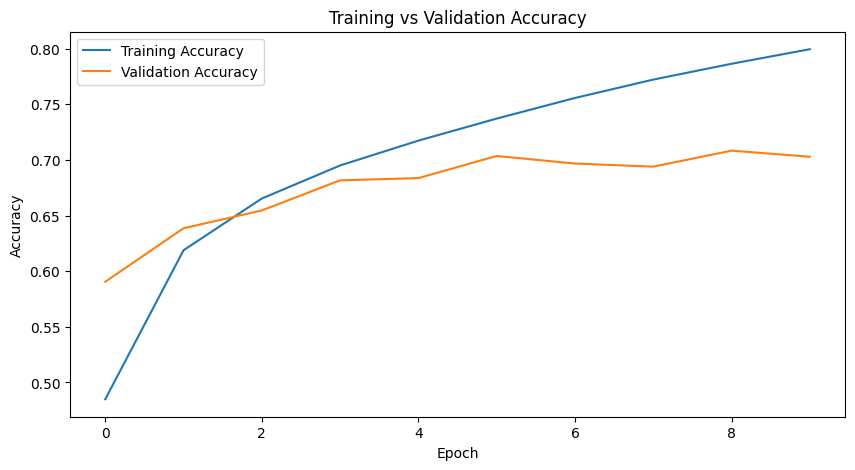

In [50]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend() #shows colour of both acccuracy
plt.show()

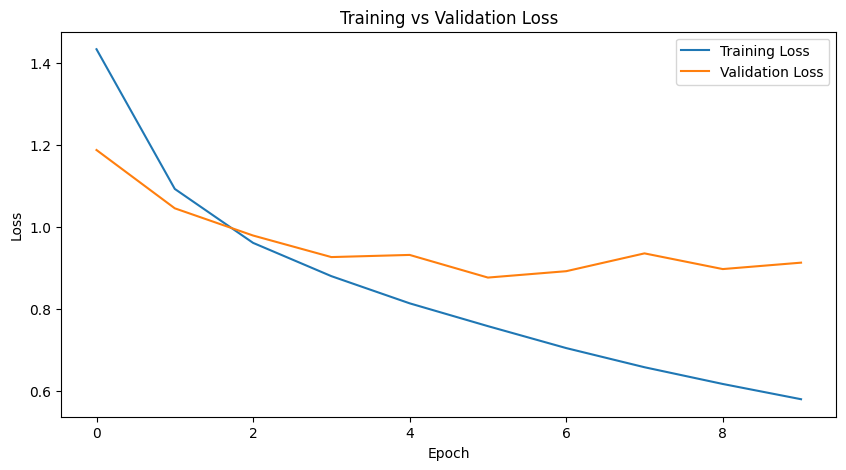

In [51]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

training Loss ↓ continuously

Validation Loss ↓ initially
                ↑ starts fluctuating

early sign of overfitting.

very minimal tho

In [52]:
#predictions
predictions = model.predict(test_images)

predicted_classes = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [53]:
#classifcation report
print(
    classification_report(
        test_labels,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.74      0.73      0.73      1000
  automobile       0.85      0.80      0.82      1000
        bird       0.56      0.62      0.59      1000
         cat       0.50      0.56      0.53      1000
        deer       0.63      0.65      0.64      1000
         dog       0.64      0.56      0.60      1000
        frog       0.74      0.80      0.77      1000
       horse       0.82      0.69      0.75      1000
        ship       0.78      0.83      0.81      1000
       truck       0.82      0.78      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



bad performance on
Cat ↔ Dog

Bird ↔ Cat

Dog ↔ Deer

confusing btw them

model achieved a test accuracy of 70.29% on the CIFAR-10 dataset. Classes such as automobile, ship, truck, and frog exhibited strong classification performance, while cat, bird, and dog showed lower F1-scores due to visual similarities and the low resolution (32×32) of CIFAR-10 images. The results indicate that the CNN effectively learned discriminative features but experienced difficulty distinguishing between visually similar animal classes.

###Improving the CNN model with batch normalizing and drop out

drop(0.25) means 25% neurons off 75% ON

In [58]:
improved_model = Sequential()

# Block 1
improved_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

improved_model.add(BatchNormalization())

improved_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu'
    )
)

improved_model.add(
    MaxPooling2D(pool_size=(2,2))
)

improved_model.add(
    Dropout(0.25)
)

# Block 2
improved_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

improved_model.add(BatchNormalization())

improved_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

improved_model.add(
    MaxPooling2D(pool_size=(2,2))
)

improved_model.add(
    Dropout(0.25)
)

# Fully Connected
improved_model.add(Flatten())

improved_model.add(
    Dense(
        128,
        activation='relu'
    )
)

improved_model.add(BatchNormalization())

improved_model.add(
    Dropout(0.5)
)

# Output
improved_model.add(
    Dense(
        10,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,682 (1.04 MB)

 Trainable params: 272,234 (1.04 MB)

 Non-trainable params: 448 (1.75 KB)

In [60]:
improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
history_v2 = improved_model.fit(
    train_images,
    train_labels,
    epochs=15,
    validation_data=(test_images, test_labels)
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 87ms/step - accuracy: 0.4505 - loss: 1.5728 - val_accuracy: 0.5417 - val_loss: 1.2767
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - accuracy: 0.6117 - loss: 1.1147 - val_accuracy: 0.6621 - val_loss: 0.9645
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 85ms/step - accuracy: 0.6621 - loss: 0.9718 - val_accuracy: 0.7115 - val_loss: 0.8372
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.6935 - loss: 0.8847 - val_accuracy: 0.7023 - val_loss: 0.8636
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - accuracy: 0.7135 - loss: 0.8288 - val_accuracy: 0.6910 - val_loss: 0.8787
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.7304 - loss: 0.7859 - val_accuracy: 0.7489 - val_loss: 0.7115
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.7424 - loss: 0.7495 - val_accuracy: 0.6975 - val_loss: 0.9397
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 

base model
Train = 80%
Test  = 70%

Gap:

10%

Improved CNN
Train = 79.2%
Validation = 79.6%

Gap:

~0%

 validation is slightly higher no prob.

In [62]:
test_loss_v2, test_accuracy_v2 = improved_model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print("Test Loss:", test_loss_v2)
print("Test Accuracy:", test_accuracy_v2)

Test Loss: 0.6156678795814514
Test Accuracy: 0.7955999970436096


In [63]:
#saving model
improved_model.save("cifar10_improved_cnn.keras")

In [64]:
predictions_v2 = improved_model.predict(test_images)

predicted_classes_v2 = np.argmax(predictions_v2, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


In [65]:
print(
    classification_report(
        test_labels,
        predicted_classes_v2,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.74      0.86      0.80      1000
  automobile       0.91      0.89      0.90      1000
        bird       0.77      0.67      0.71      1000
         cat       0.76      0.55      0.64      1000
        deer       0.74      0.78      0.76      1000
         dog       0.79      0.69      0.74      1000
        frog       0.84      0.84      0.84      1000
       horse       0.72      0.92      0.81      1000
        ship       0.89      0.85      0.87      1000
       truck       0.83      0.92      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.79     10000
weighted avg       0.80      0.80      0.79     10000



## Improved model accuracy from 70.3% to 79.6% using Batch Normalization and Dropout regularization.